In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
maxSteps = 1000000

In [3]:
numPolygons = 32
n = 32
i = 5
phi = 0.05
kappa = 3.7
m = pcp.model(size = n * numPolygons, seed = i)

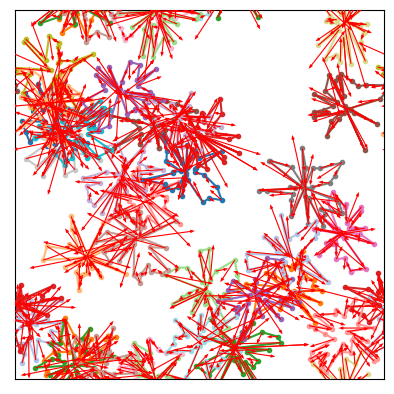

In [4]:
numPolygons = 32
n = 32
i = 5
phi = 0.05
kappa = 3.7
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("softBody")

m.generateRandomPolygons(numPolygons, n)
m.setBiPerimeters(kappa)
m.setStiffness(1)
m.setCompressibility(1)

m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
artists = m.draw(forces = m.getForces())

In [5]:
m.getEnergy()

1.0807019707674974

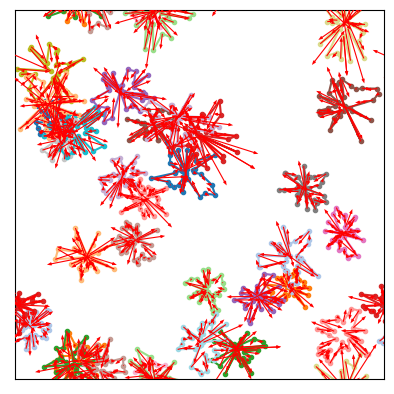

In [6]:
m.resetAreas()
m.updatePolygonGeometry()
areas = m.getAreas()
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
m.setModelEnum("softBody")
force = m.getForces()
artists = m.draw(forces = m.getForces())
m.updateForceEnergy()

In [7]:
m.setModelEnum("softBody")
m.minimizeGD(dt = 0.1, maxSteps = maxSteps, progressBar = True)

Processing:   9%|▊        | 94734/1000000 [00:41<06:35, 2287.50it/s]


1.128281499494106e-24

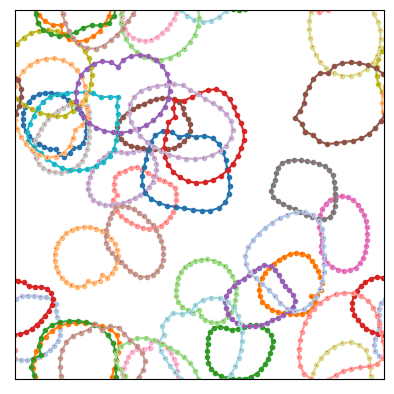

In [12]:
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
_ = m.draw(forces = force)

In [13]:
m.getMaxUnbalancedForce()

4.1808476325024814e-12

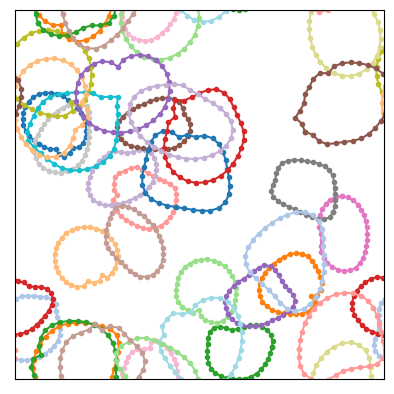

In [14]:
phi = 1.0
m.setPhi(phi)
_ = m.draw()

In [15]:
m.updatePolygonGeometry()
print(m.getConstraintViolation())

[1.77451274e-15 3.54687081e-11 3.54667506e-11]


In [16]:
m.saveModel("LMTesting", overwrite = True)

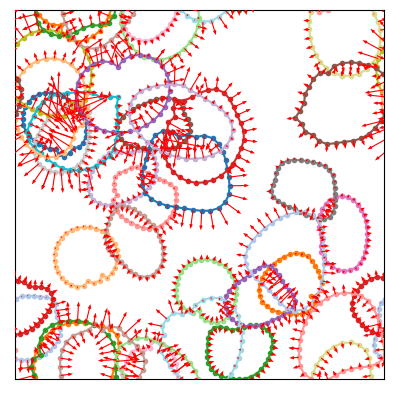

In [17]:
m.setModelEnum("normal")
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
m.projectForce()
forces = m.getForces()
_ = m.draw(forces = forces)

Processing: 100%|████████████████████| 1/1 [00:00<00:00, 392.36it/s]


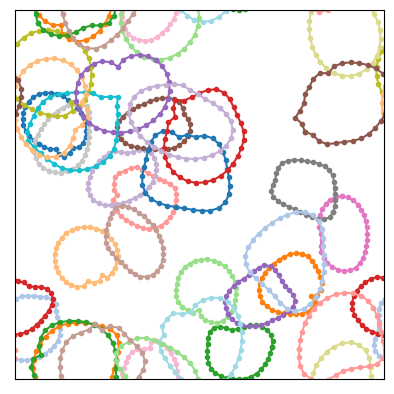

In [18]:
m.setModelEnum("normal")
m.minimizeGD(dt = 1e-6, maxSteps = 0, progressBar = True)
_ = m.draw()
plt.show()

In [19]:
m.updatePolygonGeometry()
print(m.getConstraintViolation())

[1.77451274e-15 3.54687081e-11 3.54667506e-11]


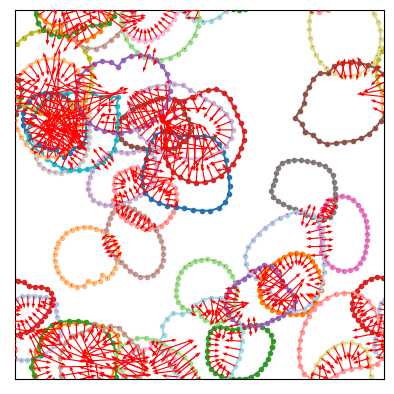

In [20]:
m.setModelEnum("normal")
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
artists = m.draw(forces = m.getForces(), arrowColor = 'r')

Processing: 100%|████████████████████| 1/1 [00:00<00:00, 279.01it/s]


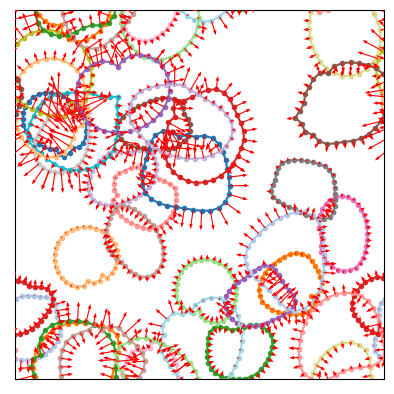

In [21]:
#for dt in np.logspace(-6, -3, 10):
#    m.setModelEnum("edgeOnly")
#    m.minimizeGD(dt = dt, maxSteps = maxSteps, progressBar = True)
m.setModelEnum("normal")
m.minimizeGD(dt = 1e-5, maxSteps = 1, progressBar = True)
_ = m.draw(forces = m.getForces())
plt.show()

In [22]:
m.getMaxUnbalancedForce(), m.getEnergy(), m.getConstraintViolation()

(0.12220757243755112,
 0.4796714707981336,
 array([1.67500704e-11, 3.63269366e-06, 5.94669940e-11]))

In [24]:
m.setModelEnum("softBody")
m.minimizeGD(dt = 0.1, maxSteps = maxSteps, progressBar = True)

Processing:   1%|          | 9561/1000000 [00:03<06:24, 2578.07it/s]


1.1679076854556398e-25

Processing: 100%|████████████████████| 1/1 [00:00<00:00, 404.35it/s]


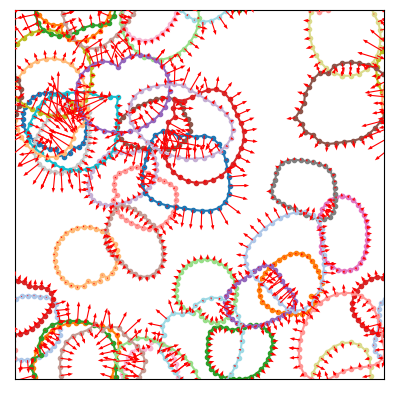

In [25]:
m.setModelEnum("normal")
m.minimizeGD(dt = 1e-4, maxSteps = 1, progressBar = True)
_ = m.draw(forces = m.getForces())
plt.show()

In [26]:
m.getMaxUnbalancedForce(), m.getEnergy(), m.getConstraintViolation()

(0.12228802415876582,
 0.4796683859260363,
 (9.73320580898058e-10, 3.671583181570982e-05))

In [23]:
def resetMinimizeGD(model, maxConstraintViolationThreshold = 0.02, maxSteps = -1):
    trials = 20
    trial = 0
    while trial < trials:
        model.setModelEnum("softBody")
        model.minimizeGD(dt = 0.1, maxConstraintViolationThreshold = maxConstraintViolationThreshold, maxSteps = 1e6, progressBar = False)
        model.setModelEnum("normal")
        model.minimizeGD(dt = 1e-4, maxConstraintViolationThreshold = maxConstraintViolationThreshold, maxSteps = maxSteps, progressBar = False)
        trial += 1
        print(trial)
    model.setModelEnum("softBody")
    model.minimizeGD(dt = 0.1, maxConstraintViolationThreshold = maxConstraintViolationThreshold, maxSteps = 1e6, progressBar = False)

In [24]:
#positions = np.load("resetMinimizeGD/0.046415888336127795/state.npy")[32:]
#m.setPositions(positions)

In [ ]:
for maxConstraintViolationThreshold in np.logspace(-1, -12, 100):
    resetMinimizeGD(m, maxSteps = 1e4, maxConstraintViolationThreshold = maxConstraintViolationThreshold)
    m.saveModel("resetMinimizeGD/" + str(maxConstraintViolationThreshold), overwrite = True)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8


In [ ]:
_ = m.draw(forces = m.getForces())
plt.show()